### Importação dos dados



In [55]:
import pandas as pd
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


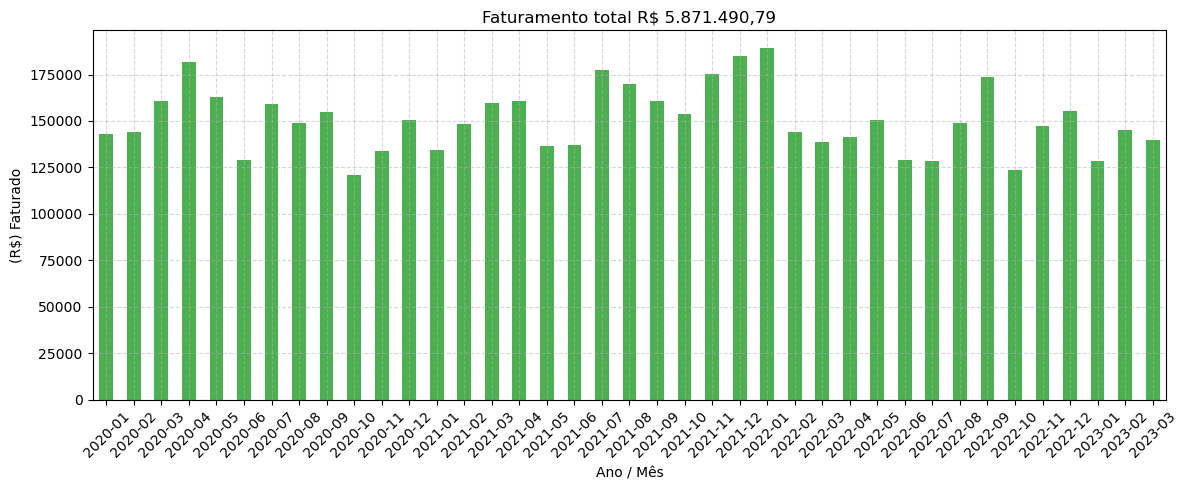

In [90]:
import matplotlib.pyplot as plt
import locale

# Definindo o locale para Brasil
locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')

#### FATURAMENTO POR PERIODO ###

# Converter a data para datetime com formato brasileiro
todas_lojas["data_da_compra"] = pd.to_datetime(todas_lojas["data_da_compra"], dayfirst=True)

# Calculando o faturamento
todas_lojas["faturamento"] = todas_lojas["preco"]

# Calculando o total faturado em todo periodo
total_faturado = round(todas_lojas['preco'].sum(),2)

# Formatando para moeda brasileira
total_faturado = locale.currency(total_faturado, grouping=True)

# Criar a coluna de período (ano/mês)
todas_lojas["ano_mes"] = todas_lojas["data_da_compra"].dt.to_period("M")

# Agrupar por mês
faturamento_mensal = todas_lojas.groupby("ano_mes")["faturamento"].sum()

# Exibir gráfico
faturamento_mensal.plot(kind="bar", figsize=(12, 5), color="#4CAF50")
plt.title(f"Faturamento total {total_faturado}")
plt.xlabel("Ano / Mês")
plt.ylabel("(R$) Faturado")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

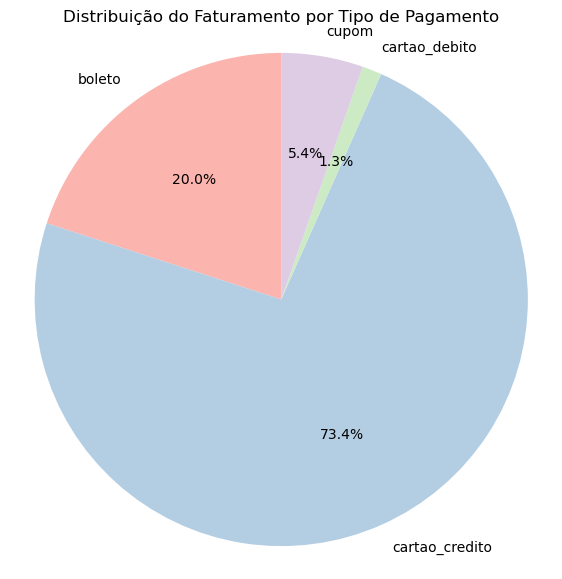

In [83]:
# Somar o valor das vendas por tipo de pagamento
faturamento_pagamento = todas_lojas.groupby("tipo_de_pagamento")["preco"].sum()

# Dicionário para exibição do grafiico
nomes_formatados = {
    "cartao_de_credito": "Cartão de Crédito",
    "boleto": "Boleto",
    "dinheiro": "Dinheiro",
    "pix": "Pix"
}
# Substituindo os rotulos
labels = [nomes_formatados.get(tipo, tipo.title()) for tipo in pagamentos.index]

# Criar gráfico de pizza
plt.figure(figsize=(7, 7))
plt.pie(faturamento_pagamento, labels=faturamento_pagamento.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
plt.title("Distribuição do Faturamento por Tipo de Pagamento")
plt.axis("equal")
plt.show()

# 2. Vendas por Categoria


                        produto    faturamento
0               Cubo mágico 8x8    R$ 3,638.68
1                Corda de pular    R$ 4,090.93
2                Dinossauro Rex    R$ 4,150.53
3             Xadrez de madeira    R$ 6,865.90
4                 Jogo de copos    R$ 7,445.28
5       Dashboards com Power BI    R$ 8,557.88
6              Blocos de montar    R$ 9,069.86
7                  Copo térmico   R$ 11,329.84
8                      Faqueiro   R$ 11,413.85
9                   Boneca bebê   R$ 11,456.05
10  Ciência de dados com python   R$ 12,049.06
11                Bola de vôlei   R$ 12,132.72
12     Iniciando em programação   R$ 12,833.09
13             Bola de basquete   R$ 13,012.07
14          Modelagem preditiva   R$ 16,820.71
15                     Pandeiro   R$ 16,884.72
16            Panela de pressão   R$ 17,238.91
17     Carrinho controle remoto   R$ 19,690.62
18                      Mochila   R$ 21,421.54
19               Fone de ouvido   R$ 22,021.81
20           

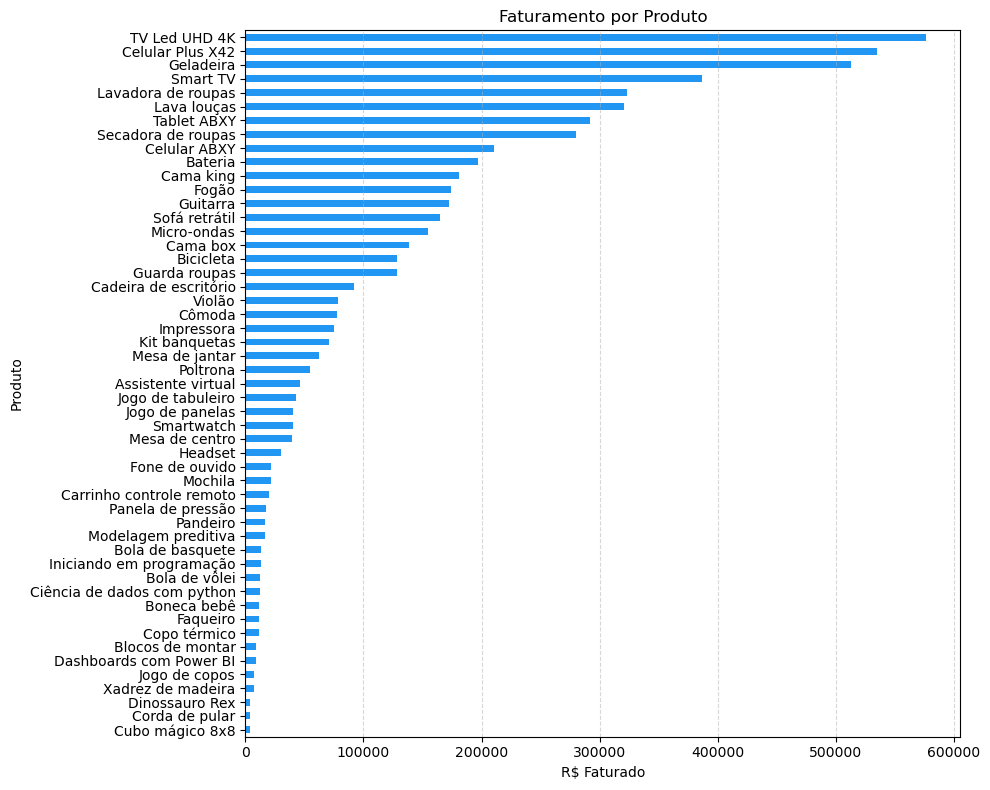

In [94]:
# Agrupar faturamento por produto
faturamento_por_produto = todas_lojas.groupby("produto")["faturamento"].sum()

# Ordenar do maior para o menor
faturamento_por_produto = faturamento_por_produto.sort_values(ascending=True)

# Criando um dataframe
df_faturamento_por_produto = faturamento_por_produto.reset_index()

# Formatando a coluna de faturamento para R$
df_faturamento_por_produto['faturamento'] = df_faturamento_por_produto['faturamento'].apply(lambda x: f"R$ {x:,.2f}")

# Exibir dataframe criado
print(df_faturamento_por_produto)

# Exibir gráfico
plt.figure(figsize=(10, 8))
faturamento_por_produto.plot(kind="barh", color="#2196F3")
plt.title("Faturamento por Produto")
plt.xlabel("R$ Faturado")
plt.ylabel("Produto")
plt.grid(True, axis='x', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

,produto,categoria_do_produto,preco,frete,data_da_compra,vendedor,local_da_compra,avaliacao_da_compra,tipo_de_pagamento,quantidade_de_parcelas,lat,lon,ano_mes,faturamento
0,Assistente virtual,eletronicos,219.08,9.249790,2021-01-16,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,2021-01,219.08
1,Mesa de jantar,moveis,256.35,11.234305,2022-05-18,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,2022-05,256.35
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,2021-03-15,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,2021-03,279.51
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,2022-05-03,João Souza,RS,4,boleto,1,-30.17,-53.50,2022-05,1009.99
4,Cadeira de escritório,moveis,446.99,26.964689,2020-11-07,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,2020-11,446.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2353,Mesa de jantar,moveis,303.60,16.852799,2020-02-12,Camila Ribeiro,RJ,5,cartao_credito,1,-22.25,-42.66,2020-02,303.60
2354,Cadeira de escritório,moveis,456.02,24.812798,2022-05-17,Felipe Santos,PE,5,cartao_credito,3,-8.38,-37.86,2022-05,456.02
2355,Copo térmico,esporte e lazer,48.99,3.139675,2022-05-03,Camila Ribeiro,SP,5,cartao_credito,1,-22.19,-48.79,2022-05,48.99
2356,Jogo de panelas,utilidades domesticas,202.45,11.062979,2020-06-15,Bianca Santos,PR,5,cartao_credito,1,-24.89,-51.55,2020-06,202.45


# 3. Média de Avaliação das Lojas

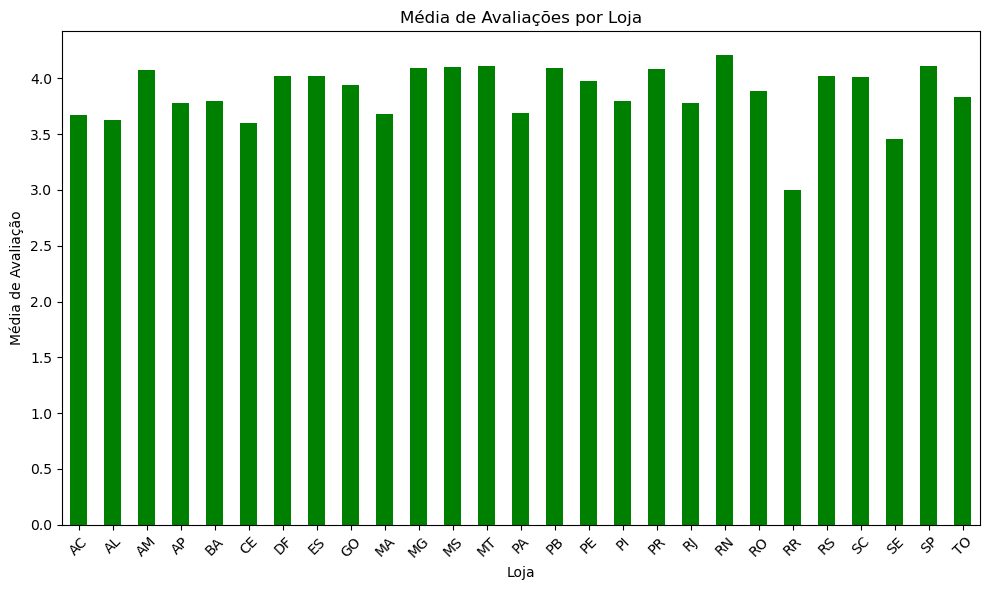

In [116]:
# Agrupando as avaliações por lojas
media_avaliacoes_lojas = round(todas_lojas.groupby('local_da_compra')['avaliacao_da_compra'].mean(),2)

# Criar um gráfico de barras para a média de avaliações por loja
plt.figure(figsize=(10, 6))
media_avaliacoes_lojas.plot(kind='bar', color='green')

# Adicionar título e rótulos ao gráfico
plt.title('Média de Avaliações por Loja')
plt.xlabel('Loja')
plt.ylabel('Média de Avaliação')
plt.xticks(rotation=45)

# Exibir o gráfico
plt.tight_layout()
plt.show()

In [117]:
# filtrar a loja com a melhor e a pior avaliações
melhor_loja = media_avaliacoes_lojas.idxmax()
melhor_avaliacao = media_avaliacoes_lojas.max()

pior_loja = media_avaliacoes_lojas.idxmin()
pior_avaliacao = media_avaliacoes_lojas.min()

# Mostrar resultados
print(f"A loja com a melhor avaliação é: {melhor_loja} com média de {melhor_avaliacao}")
print(f"A loja com a pior avaliação é: {pior_loja} com média de {pior_avaliacao}")

A loja com a melhor avaliação é: RN com média de 4.21
A loja com a pior avaliação é: RR com média de 3.0


# 4. Produtos Mais e Menos Vendidos

In [119]:
# Soma a quantidade de vendas por produto
vendas_por_produto = todas_lojas["produto"].value_counts()

# Exibir o produto mais e menos vendidos
produto_mais_vendido = vendas_por_produto.idxmax()
quantidade_mais_vendido = vendas_por_produto.max()

produto_menos_vendido = vendas_por_produto.idxmin()
quantidade_menos_vendido = vendas_por_produto.min()

# Mostrar os resultados
print(f"O produto mais vendido é: {produto_mais_vendido} com {quantidade_mais_vendido} vendas.")
print(f"O produto menos vendido é: {produto_menos_vendido} com {quantidade_menos_vendido} vendas.")

O produto mais vendido é: Cômoda com 210 vendas.
O produto menos vendido é: Celular ABXY com 157 vendas.


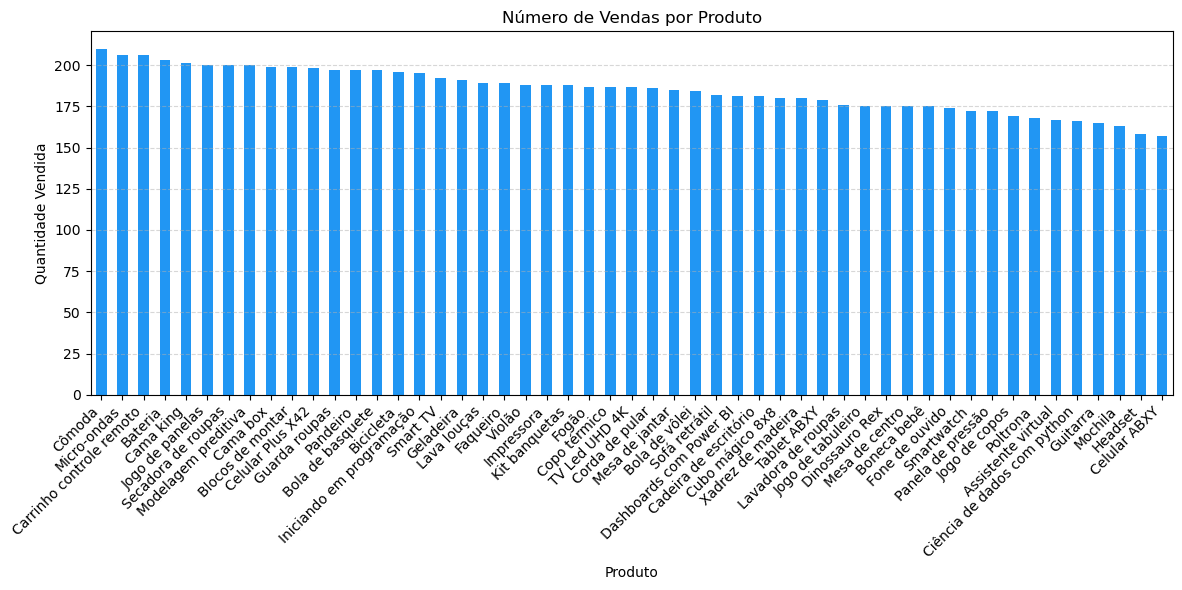

In [121]:
# Criar o gráfico
plt.figure(figsize=(12, 6))
vendas_por_produto.plot(kind="bar", color="#2196F3")  # Azul
plt.title("Número de Vendas por Produto")
plt.xlabel("Produto")
plt.ylabel("Quantidade Vendida")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 5. Frete Médio por Loja


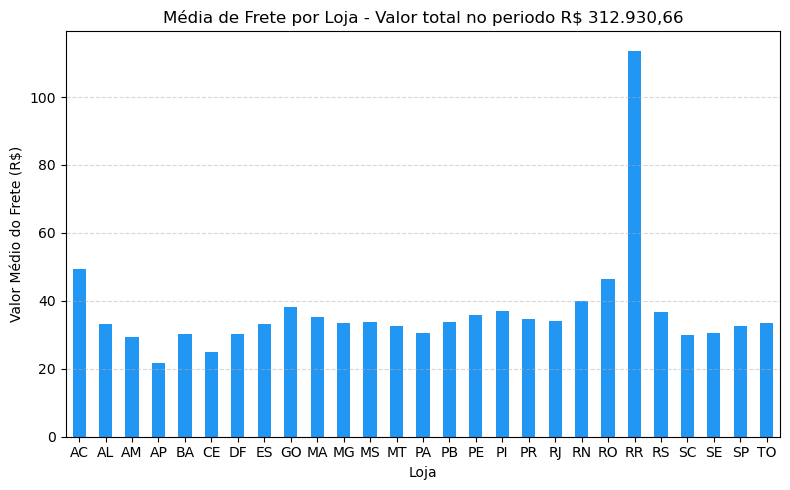

In [133]:
# Calculando a media de frete por loja
media_frete_por_loja = todas_lojas.groupby("local_da_compra")["frete"].mean().round(2)

total_frete = round(todas_lojas['frete'].sum(),2)

# Formatando para moeda real
total_frete = locale.currency(total_frete, grouping=True)

# Gráfico da média de frete por loja
media_frete_por_loja.plot(
    kind="bar",
    color="#2196F3",  # Azul
    figsize=(8, 5)
)

plt.title(f"Média de Frete por Loja - Valor total no periodo {total_frete}")
plt.xlabel("Loja")
plt.ylabel("Valor Médio do Frete (R$)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

'R$ 312.930,66'